In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

In [2]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/'

In [3]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

Species names

In [4]:
O_list = ['OI', 'OII', 'OIII', 'OIV', 'OV', 'OVI', 'OVII', 'OVIII', 'OIX']

O_species = [r'$\mathrm{O}^0$', r'$\mathrm{O}^+$', r'$\mathrm{O}^{2+}$', r'$\mathrm{O}^{3+}$',
            r'$\mathrm{O}^{4+}$', r'$\mathrm{O}^{5+}$', r'$\mathrm{O}^{6+}$',
            r'$\mathrm{O}^{7+}$', r'$\mathrm{O}^{8+}$']

In [5]:
C_list = ['CI', 'CII', 'CIII', 'CIV', 'CV', 'CVI', 'CVII']

C_species = [r'$\mathrm{C}^0$', r'$\mathrm{C}^+$', r'$\mathrm{C}^{2+}$', r'$\mathrm{C}^{3+}$',
            r'$\mathrm{C}^{4+}$', r'$\mathrm{C}^{5+}$', r'$\mathrm{C}^{6+}$', r'$\mathrm{C}^{6+}$'] 

# Collisional ionization equilibrium

Load CLOUDY grid

In [6]:
f = open(rootdir+'cloudy_grids/non_eqm_models/CI/CIE/CIE_frac.grd', 'r')
L = f.readlines()
f.close()

T_grid_CIE = 10**np.array([float(L[i].split('\t')[-2]) for i in range(1, len(L))])

In [7]:
X_dict_CIE = {k:np.zeros(len(T_grid_CIE)) for k in O_list}

f = open(rootdir+'cloudy_grids/non_eqm_models/CI/CIE/CIE_frac.oxy', 'r')
L = f.readlines()
f.close()

for s in O_list:
    for i in range(len(T_grid_CIE)):
        X_dict_CIE[s][i] = float(L[i+1].split('\t')[O_list.index(s)+1])

In [8]:
colors_list = ['black', 'black', 'dodgerblue', 'dodgerblue', 
               'forestgreen', 'forestgreen', 'firebrick', 'firebrick', 
               'tan']
ls_list = ['-', '--', '-', '--', '-', '--', '-', '--', '-', '--', '-']

Load GS07

In [9]:
gs07_table_CIE = np.loadtxt(rootdir+'gs07_grids/table2a.dat')

In [10]:
T_grid_gs07_CIE = gs07_table_CIE[:,0]

In [11]:
X_dict_gs07_CIE = {k:np.zeros(len(T_grid_gs07_CIE)) for k in O_list}

for i in range(len(O_list)):
    s = O_list[i]
    X_dict_gs07_CIE[s] = gs07_table_CIE[:,21+i]

Compare ion fractions

In [12]:
colors_list = ['black', 'black', 'dodgerblue', 'dodgerblue', 
               'forestgreen', 'forestgreen', 'firebrick', 'firebrick', 
               'tan']
ls_list = ['-', '--', '-', '--', '-', '--', '-', '--', '-', '--', '-']

In [13]:
x_list_CIE = [1.3e+4, 3e+4, 7e+4, 1.3e+5, 2.2e+5, 4.6e+5, 8e+5, 2e+6, 3e+6]
y_list_CIE = [1.1e0, 1.1e+0, 9.2e-1, 8e-1, 6e-1, 1e-1, 1.1e+0, 5e-1, 9.8e-1]

(0.0012589254117941675, 1.9952623149688795)

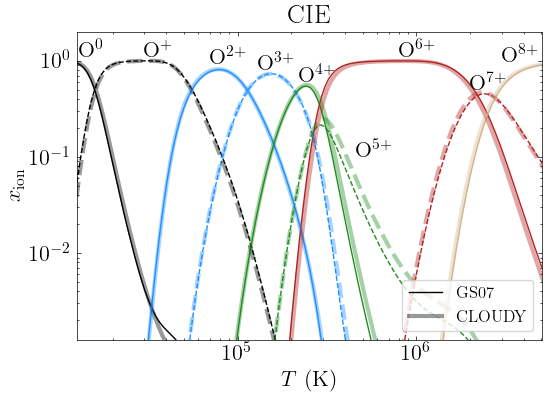

In [14]:
fig, ax = plt.subplots(1, figsize=(6,4))

for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'GS07'
    else:
        l = None
    
    ax.plot(T_grid_gs07_CIE, X_dict_gs07_CIE[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=l)
    
    ax.text(x_list_CIE[i], y_list_CIE[i], O_species[i])
    
for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'CLOUDY'
    else:
        l = None
    
    ax.plot(T_grid_CIE, X_dict_CIE[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], lw=3, alpha=.4, label=l)    
    
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='lower right')#, bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$x_\mathrm{ion}$')
    
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_title(r'CIE')
    
ax.set_xlim(10**4.1,10**6.7)
ax.set_ylim(10**-2.9, 10**0.3)

(0.0012589254117941675, 1.5848931924611136)

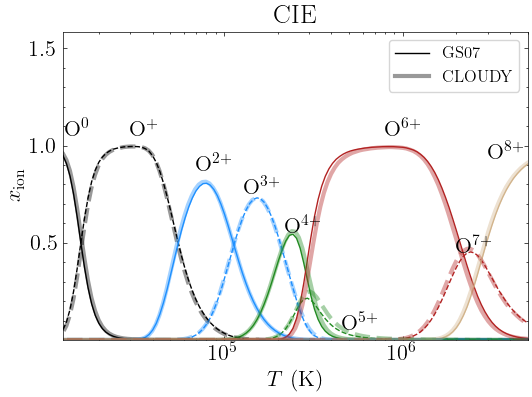

In [15]:
fig, ax = plt.subplots(1, figsize=(6,4))

for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'GS07'
    else:
        l = None
    
    ax.plot(T_grid_gs07_CIE, X_dict_gs07_CIE[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=l)
    
    ax.text(x_list_CIE[i], y_list_CIE[i]-0.05, O_species[i])
    
for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'CLOUDY'
    else:
        l = None
    
    ax.plot(T_grid_CIE, X_dict_CIE[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], lw=3, alpha=.4, label=l)    
    
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='upper right')#, bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$x_\mathrm{ion}$')
    
ax.set_xscale('log')
#ax.set_yscale('log')

ax.set_title(r'CIE')
    
ax.set_xlim(10**4.1,10**6.7)
ax.set_ylim(10**-2.9, 10**0.2)

# Non-equilibrium collisional ionization (isochoric)

Read in temperature grid

In [16]:
f = open(rootdir+'cloudy_grids/non_eqm_models/CI/TDC_isochoric/TDC_isochoric_frac.tim', 'r')
L = f.readlines()
f.close()

In [17]:
T_grid_TDC_isochoric = np.array([L[i].split('\t')[4] for i in range(1, len(L))], dtype=float)

Read in ion fractions

In [18]:
X_dict_TDC_isochoric = {k:np.zeros(len(T_grid_TDC_isochoric)) for k in O_list}

In [20]:
f = open(rootdir+'cloudy_grids/non_eqm_models/CI/TDC_isochoric/TDC_isochoric_frac.oxy', 'r')
L = f.readlines()
f.close()

for s in O_list:
    for i in range(len(T_grid_TDC_isochoric)):
        X_dict_TDC_isochoric[s][i] = float(L[i+1].split('\t')[O_list.index(s)+1])

Load in the ion fractions for Gnat and Sternberg 2007

In [21]:
gs07_table_TDC_isochoric = np.loadtxt(rootdir+'gs07_grids/table2b.dat')

In [22]:
T_grid_gs07_TDC_isochoric = gs07_table_TDC_isochoric[:,0]

In [23]:
X_dict_gs07_TDC_isochoric = {k:np.zeros(len(T_grid_gs07_TDC_isochoric)) for k in O_list}

for i in range(len(O_list)):
    s = O_list[i]
    X_dict_gs07_TDC_isochoric[s] = gs07_table_TDC_isochoric[:,21+i]

In [24]:
x_list_TDC_isochoric = [1.1e+4, 1.5e+4, 6e+4, 1.2e+5, 2.2e+5, 4e+5, 8e+5, 1.1e+6, 3e+6]
y_list_TDC_isochoric = [2e-1, 1.1e+0, 8.5e-1, 6.7e-1, 3e-1, 1e-1, 1.1e+0, 3.5e-1, 1e+0]

(0.0012589254117941675, 1.9952623149688795)

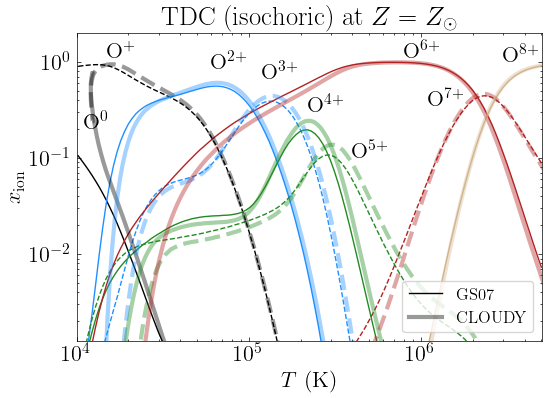

In [27]:
fig, ax = plt.subplots(1, figsize=(6,4))

for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'GS07'
    else:
        l = None
    
    ax.plot(T_grid_gs07_TDC_isochoric, X_dict_gs07_TDC_isochoric[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=l)
    
    ax.text(x_list_TDC_isochoric[i], y_list_TDC_isochoric[i], O_species[i])
    
for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'CLOUDY'
    else:
        l = None
    
    ax.plot(T_grid_TDC_isochoric, X_dict_TDC_isochoric[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], lw=3, alpha=.4, label=l)    
    
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='lower right')#, bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$x_\mathrm{ion}$')
    
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_title(r'TDC (isochoric) at $Z=Z_\odot$')
    
ax.set_xlim(10**4,10**6.7)
ax.set_ylim(10**-2.9, 10**0.3)

(0.0012589254117941675, 1.4791083881682074)

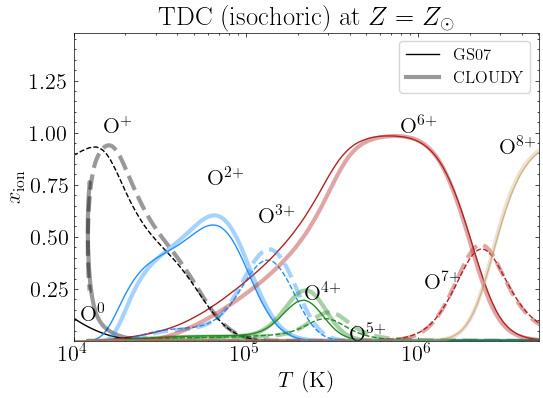

In [28]:
fig, ax = plt.subplots(1, figsize=(6,4))

for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'GS07'
    else:
        l = None
    
    ax.plot(T_grid_gs07_TDC_isochoric, X_dict_gs07_TDC_isochoric[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=l)
    
    ax.text(x_list_TDC_isochoric[i], y_list_TDC_isochoric[i]-0.1, O_species[i])
    
for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'CLOUDY'
    else:
        l = None
    
    ax.plot(T_grid_TDC_isochoric, X_dict_TDC_isochoric[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], lw=3, alpha=.4, label=l)    
    
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='upper right')#, bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$x_\mathrm{ion}$')
    
ax.set_xscale('log')
#ax.set_yscale('log')

ax.set_title(r'TDC (isochoric) at $Z=Z_\odot$')
    
ax.set_xlim(10**4,10**6.7)
ax.set_ylim(10**-2.9, 10**0.17)

# Non-equilibrium collisional ionization (isobaric)

Read in temperature grid

In [29]:
f = open(rootdir+'cloudy_grids/non_eqm_models/CI/TDC_isobaric/TDC_isobaric_frac.tim', 'r')
L = f.readlines()
f.close()

In [30]:
T_grid_TDC_isobaric = np.array([L[i].split('\t')[4] for i in range(1, len(L))], dtype=float)

Read in ion fractions

In [31]:
X_dict_TDC_isobaric = {k:np.zeros(len(T_grid_TDC_isobaric)) for k in O_list}

In [32]:
f = open(rootdir+'cloudy_grids/non_eqm_models/CI/TDC_isobaric/TDC_isobaric_frac.oxy', 'r')
L = f.readlines()
f.close()

for s in O_list:
    for i in range(len(T_grid_TDC_isobaric)):
        X_dict_TDC_isobaric[s][i] = float(L[i+1].split('\t')[O_list.index(s)+1])

Load in the ion fractions for Gnat and Sternberg 2007

In [33]:
gs07_table_TDC_isobaric = np.loadtxt(rootdir+'gs07_grids/table2c.dat')

In [34]:
T_grid_gs07_TDC_isobaric = gs07_table_TDC_isobaric[:,0]

In [35]:
X_dict_gs07_TDC_isobaric = {k:np.zeros(len(T_grid_gs07_TDC_isobaric)) for k in O_list}

for i in range(len(O_list)):
    s = O_list[i]
    X_dict_gs07_TDC_isobaric[s] = gs07_table_TDC_isobaric[:,21+i]

In [36]:
x_list_TDC_isobaric = [1.1e+4, 1.5e+4, 6e+4, 1.2e+5, 2.2e+5, 4e+5, 8e+5, 1.1e+6, 3e+6]
y_list_TDC_isobaric = [2e-1, 1.1e+0, 8.5e-1, 6.7e-1, 3e-1, 1e-1, 1.1e+0, 3.5e-1, 1e+0]

(0.0012589254117941675, 1.9952623149688795)

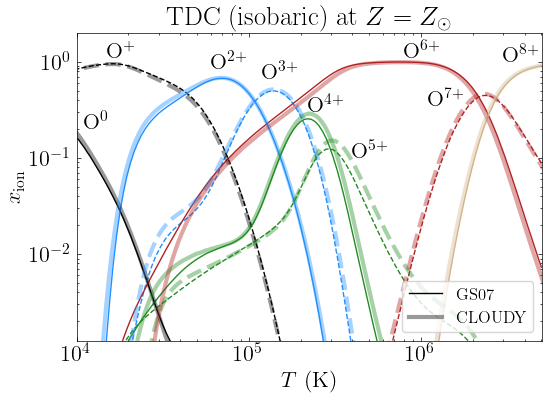

In [37]:
fig, ax = plt.subplots(1, figsize=(6,4))

for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'GS07'
    else:
        l = None
    
    ax.plot(T_grid_gs07_TDC_isobaric, X_dict_gs07_TDC_isobaric[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=l)
    
    ax.text(x_list_TDC_isobaric[i], y_list_TDC_isobaric[i], O_species[i])
    
for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'CLOUDY'
    else:
        l = None
    
    ax.plot(T_grid_TDC_isobaric, X_dict_TDC_isobaric[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], lw=3, alpha=.4, label=l)    
    
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='lower right')#, bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$x_\mathrm{ion}$')
    
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_title(r'TDC (isobaric) at $Z=Z_\odot$')
    
ax.set_xlim(10**4,10**6.7)
ax.set_ylim(10**-2.9, 10**0.3)

(0.0012589254117941675, 1.5488166189124815)

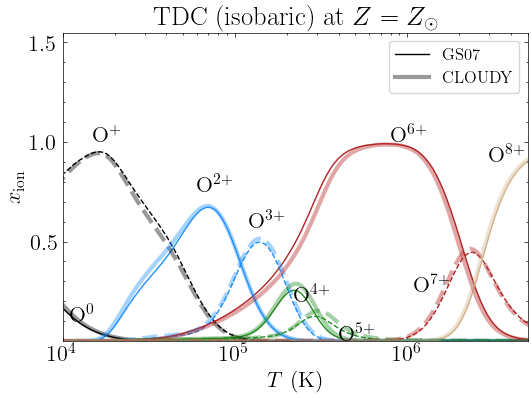

In [38]:
fig, ax = plt.subplots(1, figsize=(6,4))

for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'GS07'
    else:
        l = None
    
    ax.plot(T_grid_gs07_TDC_isobaric, X_dict_gs07_TDC_isobaric[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=l)
    
    ax.text(x_list_TDC_isobaric[i], y_list_TDC_isobaric[i]-0.1, O_species[i])
    
for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'CLOUDY'
    else:
        l = None
    
    ax.plot(T_grid_TDC_isobaric, X_dict_TDC_isobaric[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], lw=3, alpha=.4, label=l)    
    
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='upper right')#, bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$x_\mathrm{ion}$')
    
ax.set_xscale('log')
#ax.set_yscale('log')

ax.set_title(r'TDC (isobaric) at $Z=Z_\odot$')
    
ax.set_xlim(10**4,10**6.7)
ax.set_ylim(10**-2.9, 10**0.19)

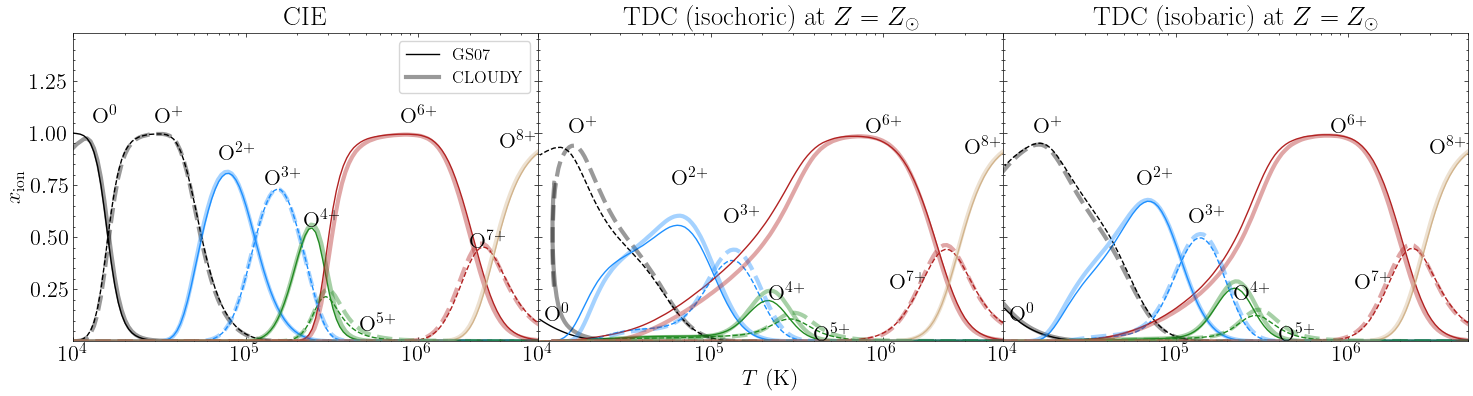

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(6*3, 4), sharex=True, sharey=True)

# CIE 

for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'GS07'
    else:
        l = None
    
    axes[0].plot(T_grid_gs07_CIE, X_dict_gs07_CIE[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=l)
    
    axes[0].text(x_list_CIE[i], y_list_CIE[i]-0.05, O_species[i])
    
for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'CLOUDY'
    else:
        l = None
    
    axes[0].plot(T_grid_CIE, X_dict_CIE[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], lw=3, alpha=.4, label=l)    
    
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
axes[0].legend(loc='upper right')#, bbox_to_anchor=(1, 0.5))
   
axes[0].set_xscale('log')
#ax.set_yscale('log')

axes[0].set_title(r'CIE')
    
axes[0].set_xlim(10**4,10**6.7)
axes[0].set_ylim(10**-2.9, 10**0.17)

# TDC isochoric

for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'GS07'
    else:
        l = None
    
    axes[1].plot(T_grid_gs07_TDC_isochoric, X_dict_gs07_TDC_isochoric[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=l)
    
    axes[1].text(x_list_TDC_isochoric[i], y_list_TDC_isochoric[i]-0.1, O_species[i])
    
for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'CLOUDY'
    else:
        l = None
    
    axes[1].plot(T_grid_TDC_isochoric, X_dict_TDC_isochoric[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], lw=3, alpha=.4, label=l)    
    
axes[1].set_title(r'TDC (isochoric) at $Z=Z_\odot$')

# TDC isobaric

for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'GS07'
    else:
        l = None
    
    axes[2].plot(T_grid_gs07_TDC_isobaric, X_dict_gs07_TDC_isobaric[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=l)
    
    axes[2].text(x_list_TDC_isobaric[i], y_list_TDC_isobaric[i]-0.1, O_species[i])
    
for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'CLOUDY'
    else:
        l = None
    
    axes[2].plot(T_grid_TDC_isobaric, X_dict_TDC_isobaric[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], lw=3, alpha=.4, label=l)    
    
axes[2].set_title(r'TDC (isobaric) at $Z=Z_\odot$')

# Axes labels 

ax_label = fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axes
ax_label.set_xticks([])
ax_label.set_yticks([])

ax_label.set_xlabel(r'$T \ (\mathrm{K})$', labelpad=20)
ax_label.set_ylabel(r'$x_\mathrm{ion}$', labelpad=35)

plt.subplots_adjust(wspace=0, hspace=0)

# Interlude - cooling curves

Load in cooling efficiencies for oxygen ions

In [40]:
T_grid_lam = 10**np.arange(4, 8.02, 0.02)

with open(rootdir+'cloudy_grids/non_eqm_models/cooling_eff/lam_oxy.pkl', 'rb') as f:
    lam_dict = pickle.load(f)

Load in cooling efficiencies from GF12

In [41]:
gf12_table = np.loadtxt(rootdir+'gf12_grids/table1h.dat')
T_grid_lam_gf12 = gf12_table[:,0]
lam_dict_gf12 = {s:gf12_table[:,O_list.index(s)+1] for s in O_list}

## CIE cooling curve

Construct weighted cooling efficiencies - both CLOUDY CIE fractions and cooling efficiencies are defined at the same temperatures

In [42]:
lam_dict_CIE = {s:lam_dict[s]*X_dict_CIE[s] for s in O_list}

Interpolate GF12 cooling efficiencies to GS07 ion fractions and construct weighted cooling efficiencies

In [43]:
lam_dict_gf12_interp = {s:np.interp(T_grid_gs07_CIE, T_grid_lam_gf12, lam_dict_gf12[s]) for s in O_list}
lam_dict_CIE_gnat = {s:lam_dict_gf12_interp[s]*X_dict_gs07_CIE[s] for s in O_list}

Calculate summed elemental cooling efficiency

In [44]:
lam_tot_CIE = np.sum(np.array(list(lam_dict_CIE.values())), axis=0)
lam_tot_CIE_gnat = np.sum(np.array(list(lam_dict_CIE_gnat.values())), axis=0)

Plot weighted cooling efficiencies

In [45]:
x_list_CIE_cooling = [1.7e+4, 2e+4, 6.5e+4, 1.5e+5, 3.5e+5, 5e+5, 2e+6, 5e+6, 4.5e+7]
y_list_CIE_cooling = [3e-21, 5e-20, 2.5e-19, 6e-19, 4e-19, 5e-20, 1e-20, 1e-20, 2e-21]

(5e-24, 3e-18)

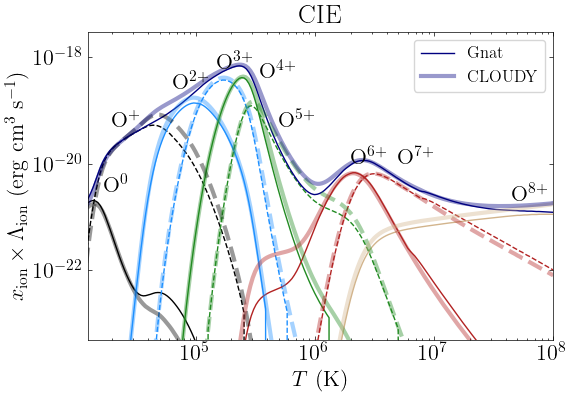

In [46]:
fig, ax = plt.subplots(1, figsize=(6,4))

for i in range(len(O_list)):
    
    s = O_list[i]
    
    ax.plot(T_grid_gs07_CIE, lam_dict_CIE_gnat[s], 
            color=colors_list[i], 
            linestyle = ls_list[i])
    
    ax.text(x_list_CIE_cooling[i], y_list_CIE_cooling[i], O_species[i])
    
ax.plot(T_grid_gs07_CIE, lam_tot_CIE_gnat, color='navy', label='Gnat')
    
for i in range(len(O_list)):
    
    s = O_list[i]
    
    ax.plot(T_grid_CIE, lam_dict_CIE[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], lw=3, alpha=.4)    
    
ax.plot(T_grid_CIE, lam_tot_CIE, color='navy', label='CLOUDY', lw=3, alpha=.4)
    
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='upper right')#, bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$x_\mathrm{ion} \times \Lambda_{\mathrm{ion}} \ (\mathrm{erg} \ \mathrm{cm}^{3} \ \mathrm{s}^{-1})$')
    
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_title(r'CIE')
    
ax.set_xlim(10**4.1,10**8)
ax.set_ylim(5e-24,3e-18)

(5e-24, 8e-19)

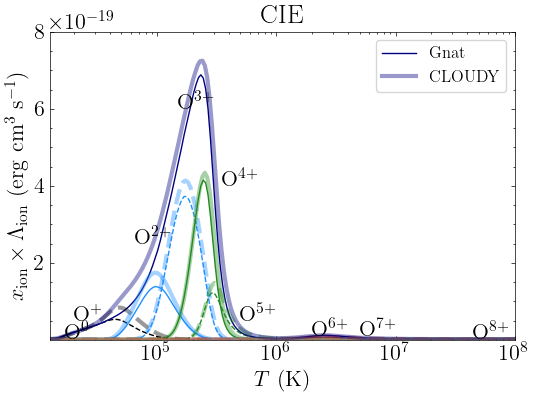

In [47]:
fig, ax = plt.subplots(1, figsize=(6,4))

for i in range(len(O_list)):
    
    s = O_list[i]
    
    ax.plot(T_grid_gs07_CIE, lam_dict_CIE_gnat[s], 
            color=colors_list[i], 
            linestyle = ls_list[i])
    
    ax.text(x_list_CIE_cooling[i], y_list_CIE_cooling[i], O_species[i])
    
ax.plot(T_grid_gs07_CIE, lam_tot_CIE_gnat, color='navy', label='Gnat')
    
for i in range(len(O_list)):
    
    s = O_list[i]
    
    ax.plot(T_grid_CIE, lam_dict_CIE[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], lw=3, alpha=.4)    
    
ax.plot(T_grid_CIE, lam_tot_CIE, color='navy', label='CLOUDY', lw=3, alpha=.4)
    
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='upper right')#, bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$x_\mathrm{ion} \times \Lambda_{\mathrm{ion}} \ (\mathrm{erg} \ \mathrm{cm}^{3} \ \mathrm{s}^{-1})$')
    
ax.set_xscale('log')
#ax.set_yscale('log')

ax.set_title(r'CIE')
    
ax.set_xlim(10**4.1,10**8)
ax.set_ylim(5e-24,8e-19)

# Non-equilibrium oxygen ion fractions - HM12

Read in temperature grid

In [50]:
f = open(rootdir+'cloudy_grids/non_eqm_models/PI/TDP/hm12/log_hdens=-3/cd-cool-1keV.tim', 'r')
L = f.readlines()
f.close()

In [51]:
T_grid_TDP_hm12 = np.array([L[i].split('\t')[4] for i in range(1, len(L))], dtype=float)

Read in ion fractions

In [52]:
X_dict_TDP_hm12 = {k:np.zeros(len(T_grid_TDP_hm12)) for k in O_list}

In [53]:
f = open(rootdir+'cloudy_grids/non_eqm_models/PI/TDP/hm12/log_hdens=-3/cd-cool-1keV.oxy', 'r')
L = f.readlines()
f.close()

for s in O_list:
    for i in range(len(T_grid_TDP_hm12)):
        X_dict_TDP_hm12[s][i] = float(L[i+1].split('\t')[O_list.index(s)+1])

Load Gnat and 2017

In [56]:
g17_table = np.loadtxt(rootdir+'g17_grids/table11_114.dat')

In [57]:
T_grid_g17 = g17_table[:,0]

In [58]:
X_dict_g17 = {k:np.zeros(len(T_grid_g17)) for k in O_list}

for i in range(len(O_list)):
    s = O_list[i]
    X_dict_g17[s] = g17_table[:,21+i]

In [59]:
x_list_TDP_hm12 = [1.1e+4, 9e+4, 3e+4, 9e+4, 2e+5, 4e+5, 8e+5, 1.1e+6, 3e+6]
y_list_TDP_hm12 = [2e-6, 1e-2, 3e-1, 5e-1, 3e-1, 1e-1, 1e+0, 3.5e-1, 1e+0]

(0.0012589254117941675, 1.9952623149688795)

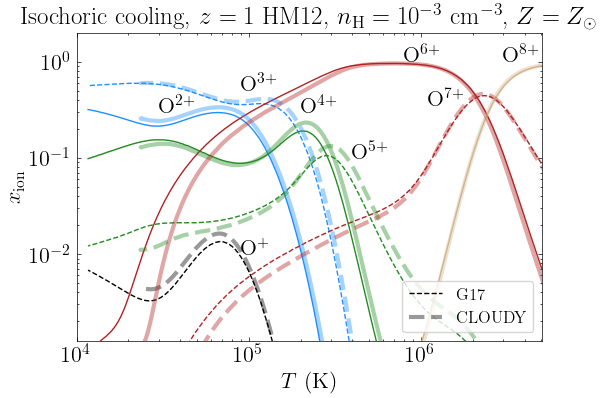

In [60]:
fig, ax = plt.subplots(1, figsize=(6,4))

for i in range(1,len(O_list)):
    
    s = O_list[i]
    
    if i==1:
        l = 'G17'
    else:
        l = None
    
    ax.plot(T_grid_g17, X_dict_g17[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=l)
    
    ax.text(x_list_TDP_hm12[i], y_list_TDP_hm12[i], O_species[i])
    
for i in range(1,len(O_list)):
    
    s = O_list[i]
    
    if i==1:
        l = 'CLOUDY'
    else:
        l = None
    
    ax.plot(T_grid_TDP_hm12, X_dict_TDP_hm12[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], lw=3, alpha=.4, label=l)    
    
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='lower right')#, bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$x_\mathrm{ion}$')
    
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_title(r'Isochoric cooling, $z=1$ HM12, $n_\mathrm{H}=10^{-3} \ \mathrm{cm}^{-3}$, $Z=Z_\odot$', fontsize=18)
    
ax.set_xlim(10**4,10**6.7)
ax.set_ylim(10**-2.9, 10**0.3)

(0.0012589254117941675, 1.1220184543019633)

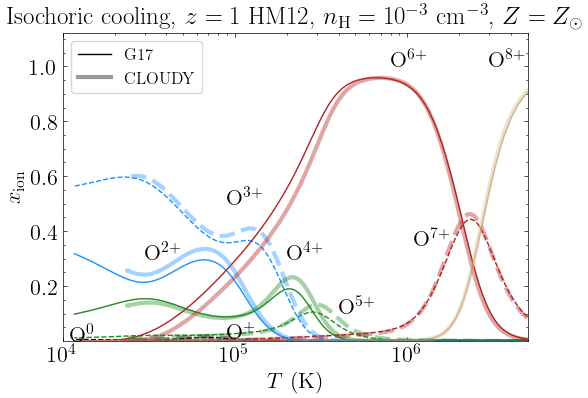

In [61]:
fig, ax = plt.subplots(1, figsize=(6,4))

for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'G17'
    else:
        l = None
    
    ax.plot(T_grid_g17, X_dict_g17[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=l)
    
    ax.text(x_list_TDP_hm12[i], y_list_TDP_hm12[i], O_species[i])
    
for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'CLOUDY'
    else:
        l = None
    
    ax.plot(T_grid_TDP_hm12, X_dict_TDP_hm12[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], lw=3, alpha=.4, label=l)    
    
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='upper left')#, bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$x_\mathrm{ion}$')
    
ax.set_xscale('log')
#ax.set_yscale('log')

ax.set_title(r'Isochoric cooling, $z=1$ HM12, $n_\mathrm{H}=10^{-3} \ \mathrm{cm}^{-3}$, $Z=Z_\odot$', fontsize=18)
    
ax.set_xlim(10**4,10**6.7)
ax.set_ylim(10**-2.9, 10**0.05)

# Non-equilibrium carbon ion fractions - HM12

Read in temperature grid

In [146]:
f = open(rootdir+'cloudy_grids/non_eqm_models/PI/TDP/hm12/log_hdens=-3/cd-cool-1keV.tim', 'r')
L = f.readlines()
f.close()

In [147]:
T_grid_TDP_hm12 = np.array([L[i].split('\t')[4] for i in range(1, len(L))], dtype=float)

Read in ion fractions

In [148]:
X_dict_TDP_hm12 = {k:np.zeros(len(T_grid_TDP_hm12)) for k in C_list}

In [149]:
f = open(rootdir+'cloudy_grids/non_eqm_models/PI/TDP/hm12/log_hdens=-3/cd-cool-1keV.carb', 'r')
L = f.readlines()
f.close()

for s in C_list:
    for i in range(len(T_grid_TDP_hm12)):
        X_dict_TDP_hm12[s][i] = float(L[i+1].split('\t')[C_list.index(s)+1])

Load Gnat and 2017

In [150]:
g17_table = np.loadtxt(rootdir+'g17_grids/table11_114.dat')

In [151]:
T_grid_g17 = g17_table[:,0]

In [164]:
X_dict_g17 = {k:np.zeros(len(T_grid_g17)) for k in C_list}

for i in range(len(C_list)):
    s = C_list[i]
    X_dict_g17[s] = g17_table[:,6+i]

In [166]:
x_list_TDP_hm12 = [1.1e+4, 9e+4, 3e+4, 9e+4, 2e+5, 4e+5, 8e+5, 1.1e+6, 3e+6]
y_list_TDP_hm12 = [2e-6, 1e-2, 3e-1, 5e-1, 3e-1, 1e-1, 1e+0, 3.5e-1, 1e+0]

(0.0012589254117941675, 1.9952623149688795)

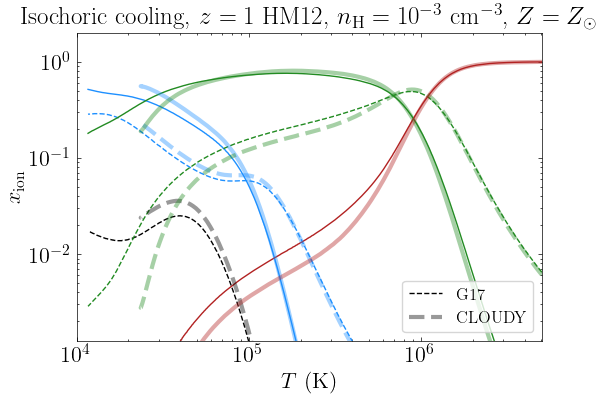

In [167]:
fig, ax = plt.subplots(1, figsize=(6,4))

for i in range(1,len(C_list)):
    
    s = C_list[i]
    
    if i==1:
        l = 'G17'
    else:
        l = None
    
    ax.plot(T_grid_g17, X_dict_g17[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=l)
    
    #ax.text(x_list_TDP_hm12[i], y_list_TDP_hm12[i], C_species[i])
    
for i in range(1,len(C_list)):
    
    s = C_list[i]
    
    if i==1:
        l = 'CLOUDY'
    else:
        l = None
    
    ax.plot(T_grid_TDP_hm12, X_dict_TDP_hm12[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], lw=3, alpha=.4, label=l)    
    
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='lower right')#, bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$x_\mathrm{ion}$')
    
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_title(r'Isochoric cooling, $z=1$ HM12, $n_\mathrm{H}=10^{-3} \ \mathrm{cm}^{-3}$, $Z=Z_\odot$', fontsize=18)
    
ax.set_xlim(10**4,10**6.7)
ax.set_ylim(10**-2.9, 10**0.3)

(0.0012589254117941675, 1.1220184543019633)

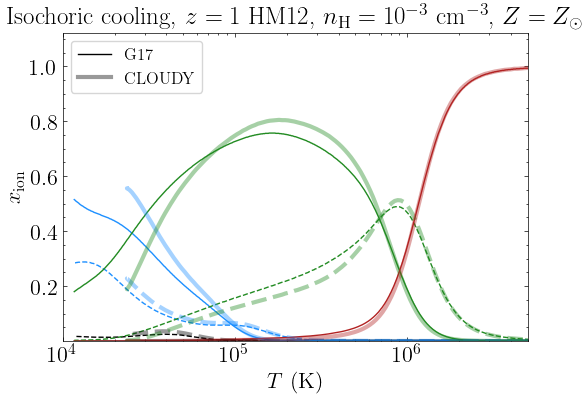

In [169]:
fig, ax = plt.subplots(1, figsize=(6,4))

for i in range(len(C_list)):
    
    s = C_list[i]
    
    if i==0:
        l = 'G17'
    else:
        l = None
    
    ax.plot(T_grid_g17, X_dict_g17[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=l)
    
    #ax.text(x_list_TDP_hm12[i], y_list_TDP_hm12[i], C_species[i])
    
for i in range(len(C_list)):
    
    s = C_list[i]
    
    if i==0:
        l = 'CLOUDY'
    else:
        l = None
    
    ax.plot(T_grid_TDP_hm12, X_dict_TDP_hm12[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], lw=3, alpha=.4, label=l)    
    
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='upper left')#, bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$x_\mathrm{ion}$')
    
ax.set_xscale('log')
#ax.set_yscale('log')

ax.set_title(r'Isochoric cooling, $z=1$ HM12, $n_\mathrm{H}=10^{-3} \ \mathrm{cm}^{-3}$, $Z=Z_\odot$', fontsize=18)
    
ax.set_xlim(10**4,10**6.7)
ax.set_ylim(10**-2.9, 10**0.05)

# Non-equilibrium oxygen ion fractions - FG20 vs. HM12

Read in temperature grid

In [62]:
f = open(rootdir+'cloudy_grids/non_eqm_models/PI/TDP/fg20/log_hdens=-3/cd-cool-1keV.tim', 'r')
L = f.readlines()
f.close()

In [63]:
T_grid_TDP_fg20 = np.array([L[i].split('\t')[4] for i in range(1, len(L))], dtype=float)

Read in ion fractions

In [64]:
X_dict_TDP_fg20 = {k:np.zeros(len(T_grid_TDP_fg20)) for k in O_list}

In [65]:
f = open(rootdir+'cloudy_grids/non_eqm_models/PI/TDP/fg20/log_hdens=-3/cd-cool-1keV.oxy', 'r')
L = f.readlines()
f.close()

for s in O_list:
    for i in range(len(T_grid_TDP_fg20)):
        X_dict_TDP_fg20[s][i] = float(L[i+1].split('\t')[O_list.index(s)+1])

Plot ion fractions

In [66]:
x_list_TDP = [1.1e+4, 9e+4, 3e+4, 9e+4, 2e+5, 4e+5, 8e+5, 1.1e+6, 3e+6]
y_list_TDP = [2e-6, 1e-2, 3e-1, 5e-1, 3e-1, 1e-1, 1e-0, 3.5e-1, 1e+0]

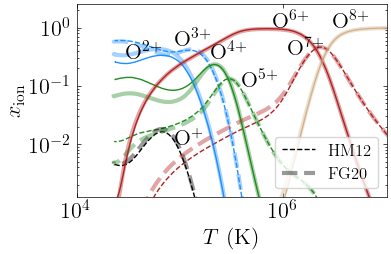

In [67]:
fig, ax = plt.subplots(1, figsize=(4,2.5))

for i in range(1,len(O_list)):
    
    s = O_list[i]
    
    if i==1:
        l = 'HM12'
    else:
        l = None
    
    ax.plot(T_grid_TDP_hm12, X_dict_TDP_hm12[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=l)
    
    ax.text(x_list_TDP[i], y_list_TDP[i], O_species[i])
    
for i in range(1,len(O_list)):
    
    s = O_list[i]
    
    if i==1:
        l = 'FG20'
    else:
        l = None
    
    ax.plot(T_grid_TDP_fg20, X_dict_TDP_fg20[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], lw=3, alpha=.4, label=l)    
    
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='lower right')#, bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$x_\mathrm{ion}$')
    
ax.set_xscale('log')
ax.set_yscale('log')

#ax.set_title(r'Isochoric cooling, $z=1$, $n_\mathrm{H}=10^{-3} \ \mathrm{cm}^{-3}$, $Z=Z_\odot$', fontsize=12)
    
ax.set_xlim(10**4,10**7)
ax.set_ylim(10**-2.9, 10**0.4)

plt.savefig(rootdir+'TDP.pdf', dpi=300)

(0.0012589254117941675, 1.1220184543019633)

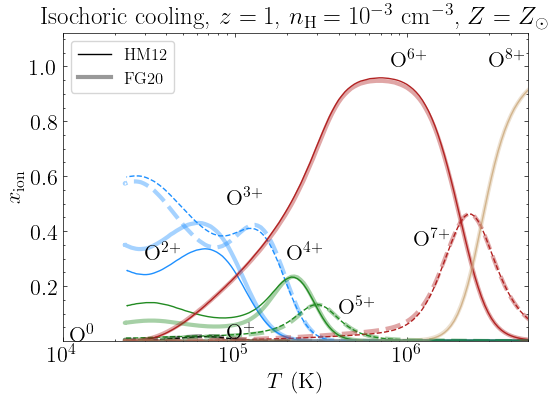

In [68]:
fig, ax = plt.subplots(1, figsize=(6,4))

for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'HM12'
    else:
        l = None
    
    ax.plot(T_grid_TDP_hm12, X_dict_TDP_hm12[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=l)
    
    ax.text(x_list_TDP[i], y_list_TDP[i], O_species[i])
    
for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'FG20'
    else:
        l = None
    
    ax.plot(T_grid_TDP_fg20, X_dict_TDP_fg20[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], lw=3, alpha=.4, label=l)    
    
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='upper left')#, bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$x_\mathrm{ion}$')
    
ax.set_xscale('log')
#ax.set_yscale('log')

ax.set_title(r'Isochoric cooling, $z=1$, $n_\mathrm{H}=10^{-3} \ \mathrm{cm}^{-3}$, $Z=Z_\odot$', fontsize=18)
    
ax.set_xlim(10**4,10**6.7)
ax.set_ylim(10**-2.9, 10**0.05)

# Non-equilibrium carbon ion fractions - FG20 vs. HM12

Read in temperature grid - HM12

In [228]:
f = open(rootdir+'cloudy_grids/non_eqm_models/PI/TDP/hm12/log_hdens=-2/cd-cool-1keV.tim', 'r')
L = f.readlines()
f.close()

In [229]:
T_grid_TDP_hm12 = np.array([L[i].split('\t')[4] for i in range(1, len(L))], dtype=float)

Read in ion fractions - HM12

In [230]:
X_dict_TDP_hm12 = {k:np.zeros(len(T_grid_TDP_hm12)) for k in C_list}

In [231]:
f = open(rootdir+'cloudy_grids/non_eqm_models/PI/TDP/hm12/log_hdens=-2/cd-cool-1keV.carb', 'r')
L = f.readlines()
f.close()

for s in C_list:
    for i in range(len(T_grid_TDP_hm12)):
        X_dict_TDP_hm12[s][i] = float(L[i+1].split('\t')[C_list.index(s)+1])

Read in temperature grid - FG20

In [232]:
f = open(rootdir+'cloudy_grids/non_eqm_models/PI/TDP/fg20/log_hdens=-2/cd-cool-1keV.tim', 'r')
L = f.readlines()
f.close()

In [233]:
T_grid_TDP_fg20 = np.array([L[i].split('\t')[4] for i in range(1, len(L))], dtype=float)

Read in ion fractions - FG20

In [234]:
X_dict_TDP_fg20 = {k:np.zeros(len(T_grid_TDP_fg20)) for k in C_list}

In [235]:
f = open(rootdir+'cloudy_grids/non_eqm_models/PI/TDP/fg20/log_hdens=-2/cd-cool-1keV.carb', 'r')
L = f.readlines()
f.close()

for s in C_list:
    for i in range(len(T_grid_TDP_fg20)):
        X_dict_TDP_fg20[s][i] = float(L[i+1].split('\t')[C_list.index(s)+1])

Plot ion fractions

In [236]:
x_list_TDP = [1.1e+4, 3e+4, 3e+4, 3e+4, 2e+5, 4e+5, 8e+5, 1.1e+6, 3e+6]
y_list_TDP = [2e-6, 1e-2, 4.2e-1, 5e-2, 9e-1, 1e-1, 1e-0, 3.5e-1, 1e+0]

(0.0012589254117941675, 2.51188643150958)

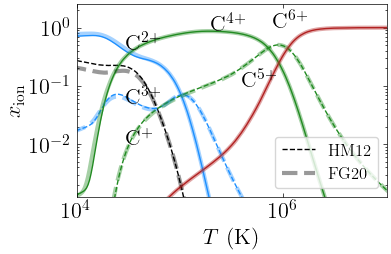

In [237]:
fig, ax = plt.subplots(1, figsize=(4,2.5))

for i in range(1,len(C_list)):
    
    s = C_list[i]
    
    if i==1:
        l = 'HM12'
    else:
        l = None
    
    ax.plot(T_grid_TDP_hm12, X_dict_TDP_hm12[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=l)
    
    ax.text(x_list_TDP[i], y_list_TDP[i], C_species[i])
    
for i in range(1,len(C_list)):
    
    s = C_list[i]
    
    if i==1:
        l = 'FG20'
    else:
        l = None
    
    ax.plot(T_grid_TDP_fg20, X_dict_TDP_fg20[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], lw=3, alpha=.4, label=l)    
    
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='lower right')#, bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$x_\mathrm{ion}$')
    
ax.set_xscale('log')
ax.set_yscale('log')

#ax.set_title(r'Isochoric cooling, $z=1$, $n_\mathrm{H}=10^{-3} \ \mathrm{cm}^{-3}$, $Z=Z_\odot$', fontsize=12)
    
ax.set_xlim(10**4,10**7)
ax.set_ylim(10**-2.9, 10**0.4)

#plt.savefig(rootdir+'TDP.pdf', dpi=300)

(0.0012589254117941675, 1.1220184543019633)

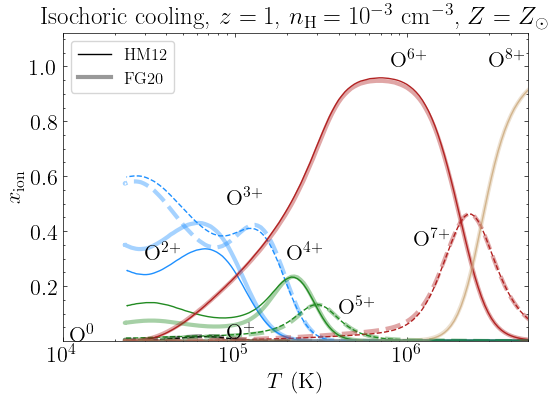

In [68]:
fig, ax = plt.subplots(1, figsize=(6,4))

for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'HM12'
    else:
        l = None
    
    ax.plot(T_grid_TDP_hm12, X_dict_TDP_hm12[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], label=l)
    
    ax.text(x_list_TDP[i], y_list_TDP[i], O_species[i])
    
for i in range(len(O_list)):
    
    s = O_list[i]
    
    if i==0:
        l = 'FG20'
    else:
        l = None
    
    ax.plot(T_grid_TDP_fg20, X_dict_TDP_fg20[s], 
            color=colors_list[i], 
            linestyle = ls_list[i], lw=3, alpha=.4, label=l)    
    
#box = ax.get_position()
#ax.set_position([box.x0, box.y0, box.width, box.height])

# Put a legend to the right of the current axis
ax.legend(loc='upper left')#, bbox_to_anchor=(1, 0.5))

ax.set_xlabel(r'$T \ (\mathrm{K})$')
ax.set_ylabel(r'$x_\mathrm{ion}$')
    
ax.set_xscale('log')
#ax.set_yscale('log')

ax.set_title(r'Isochoric cooling, $z=1$, $n_\mathrm{H}=10^{-3} \ \mathrm{cm}^{-3}$, $Z=Z_\odot$', fontsize=18)
    
ax.set_xlim(10**4,10**6.7)
ax.set_ylim(10**-2.9, 10**0.05)

# TDP vs. PIE CIV @ z=1 - G17

In [293]:
# List of ions to plot
ion_list = ['CIII', 'CIV', 'OIII', 'OIV', 'OV', 'OVI']

# Ion keys in G17 tables
iondict = {'CIII':8, 'CIV':9, 'OIII':23, 'OIV':24, 'OV':25, 'OVI':26}

# File names for different densities
filedict = {'-4':'89', '-3':'114', '-2':'139'}

In [294]:
# Store PIE temperatures and ion fractions

T_dict_PIE_g17_hm12 = {'-4':[], '-3':[], '-2':[]}

X_dict_PIE_g17_hm12 = {'-4':{'CIII':[], 'CIV':[], 'OIII':[], 'OIV':[], 'OV':[], 'OVI':[]},
                  '-3':{'CIII':[], 'CIV':[], 'OIII':[], 'OIV':[], 'OV':[], 'OVI':[]},
                  '-2':{'CIII':[], 'CIV':[], 'OIII':[], 'OIV':[], 'OV':[], 'OVI':[]}}

# Store TDP temperatures and ion fractions

T_dict_TDP_g17_hm12 = {'-4':[], '-3':[], '-2':[]}

X_dict_TDP_g17_hm12 = {'-4':{'CIII':[], 'CIV':[], 'OIII':[], 'OIV':[], 'OV':[], 'OVI':[]},
                  '-3':{'CIII':[], 'CIV':[], 'OIII':[], 'OIV':[], 'OV':[], 'OVI':[]},
                  '-2':{'CIII':[], 'CIV':[], 'OIII':[], 'OIV':[], 'OV':[], 'OVI':[]}}

# Store TDP ion fractions interpolated over PIE temperature grid

X_dict_TDP_g17_hm12_interp = {'-4':{'CIII':[], 'CIV':[], 'OIII':[], 'OIV':[], 'OV':[], 'OVI':[]},
                  '-3':{'CIII':[], 'CIV':[], 'OIII':[], 'OIV':[], 'OV':[], 'OVI':[]},
                  '-2':{'CIII':[], 'CIV':[], 'OIII':[], 'OIV':[], 'OV':[], 'OVI':[]}}

In [295]:
for i in range(len(filedict)):
    
    # Isolate density
    n = list(filedict.keys())[i]
    
    # Get file key
    f = filedict[n]
    
    # Load tables for PIE and TDP
    tab_PIE = np.loadtxt(rootdir+'g17_grids/table10_{}.dat'.format(f))
    tab_TDP = np.loadtxt(rootdir+'g17_grids/table11_{}.dat'.format(f))
    
    # Store temperatures
    T_dict_PIE_g17_hm12[n] = tab_PIE[:,0]
    T_dict_TDP_g17_hm12[n] = tab_TDP[:,0]
    
    # Store ion fractions
    for j in range(len(ion_list)):
        
        # Isolate the ion
        s = ion_list[j]
        
        # Get ion key
        k = iondict[s]
        
        X_dict_PIE_g17_hm12[n][s] = tab_PIE[:,k]
        X_dict_TDP_g17_hm12[n][s] = tab_TDP[:,k]
        
        # Interpolate while you're at it
        
        X_dict_TDP_g17_hm12_interp[n][s] = np.flip(np.interp(np.flip(T_dict_PIE_g17_hm12[n]), 
                                                 np.flip(T_dict_TDP_g17_hm12[n]), 
                                                 np.flip(X_dict_TDP_g17_hm12[n][s])))

# TDP HM12 vs. FG20 CIV @ z=1

In [296]:
# List of ions to plot
ion_list = ['CIII', 'CIV', 'OIII', 'OIV', 'OV', 'OVI']

# Ion file names and keys for CLOUDY
iondict = {'CIII':('carb', 3), 'CIV':('carb', 4), 'OIII':('oxy', 3), 'OIV':('oxy', 4), 'OV':('oxy', 5), 'OVI':('oxy', 6)}

In [350]:
# Store TDP temperatures and ion fractions for HM12

T_dict_TDP_hm12 = {'-4':[], '-3':[], '-2':[]}

X_dict_TDP_hm12 = {'-4':{'CIII':[], 'CIV':[], 'OIII':[], 'OIV':[], 'OV':[], 'OVI':[]},
                  '-3':{'CIII':[], 'CIV':[], 'OIII':[], 'OIV':[], 'OV':[], 'OVI':[]},
                  '-2':{'CIII':[], 'CIV':[], 'OIII':[], 'OIV':[], 'OV':[], 'OVI':[]}}

# Store TDP temperatures and ion fractions for FG20

T_dict_TDP_fg20 = {'-4':[], '-3':[], '-2':[]}

X_dict_TDP_fg20 = {'-4':{'CIII':[], 'CIV':[], 'OIII':[], 'OIV':[], 'OV':[], 'OVI':[]},
                  '-3':{'CIII':[], 'CIV':[], 'OIII':[], 'OIV':[], 'OV':[], 'OVI':[]},
                  '-2':{'CIII':[], 'CIV':[], 'OIII':[], 'OIV':[], 'OV':[], 'OVI':[]}}

# Interpolate FG20 over HM12
X_dict_TDP_fg20_interp = {'-4':{'CIII':[], 'CIV':[], 'OIII':[], 'OIV':[], 'OV':[], 'OVI':[]},
                  '-3':{'CIII':[], 'CIV':[], 'OIII':[], 'OIV':[], 'OV':[], 'OVI':[]},
                  '-2':{'CIII':[], 'CIV':[], 'OIII':[], 'OIV':[], 'OV':[], 'OVI':[]}}

In [352]:
for i in range(len(T_dict_TDP_hm12)):
    
    # Isolate density
    n = list(T_dict_TDP_hm12.keys())[i]
    
    # Load files for reading HM12 and FG20 temperatures
    
    # HM12 temperatures
    f = open(rootdir+'cloudy_grids/non_eqm_models/PI/TDP/hm12/log_hdens={}/cd-cool-1keV.tim'.format(n), 'r')
    L = f.readlines()
    f.close()
    
    T_dict_TDP_hm12[n] = np.array([L[i].split('\t')[4] for i in range(1, len(L))], dtype=float)
    
    # FG20 temperatures
    f = open(rootdir+'cloudy_grids/non_eqm_models/PI/TDP/fg20/log_hdens={}/cd-cool-1keV.tim'.format(n), 'r')
    L = f.readlines()
    f.close()
    
    T_dict_TDP_fg20[n] = np.array([L[i].split('\t')[4] for i in range(1, len(L))], dtype=float)
    
    # Store ion fractions
    for j in range(len(ion_list)):
        
        # Isolate the ion
        s = ion_list[j]
        
        # Get ion file and key
        ext = iondict[s][0]
        k = iondict[s][1]
        
        # HM12 ion fractions 
        f = open(rootdir+'cloudy_grids/non_eqm_models/PI/TDP/hm12/log_hdens={}/cd-cool-1keV.{}'.format(n, ext), 'r')
        L = f.readlines()
        f.close()
        
        X_dict_TDP_hm12[n][s] = np.zeros(len(T_dict_TDP_hm12[n]))
        for i in range(len(T_dict_TDP_hm12[n])):
            X_dict_TDP_hm12[n][s][i] = float(L[i+1].split('\t')[k])
            
        # FG20 ion fractions 
        f = open(rootdir+'cloudy_grids/non_eqm_models/PI/TDP/fg20/log_hdens={}/cd-cool-1keV.{}'.format(n, ext), 'r')
        L = f.readlines()
        f.close()
        
        X_dict_TDP_fg20[n][s] = np.zeros(len(T_dict_TDP_fg20[n]))
        for i in range(len(T_dict_TDP_fg20[n])):
            X_dict_TDP_fg20[n][s][i] = float(L[i+1].split('\t')[k])
            
        # Interpolate
        
        X_dict_TDP_fg20_interp[n][s] = np.flip(np.interp(np.flip(T_dict_TDP_hm12[n]), 
                                                 np.flip(T_dict_TDP_fg20[n]), 
                                                 np.flip(X_dict_TDP_fg20[n][s])))

In [354]:
colorlist = ['black', 'black', 'firebrick', 'firebrick', 'firebrick', 'firebrick']
lslist = ['-', '--', '-', '--','-.',':']

/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_34297/1100848339.py:6: RuntimeWarning: invalid value encountered in true_divide
  X_dict_TDP_g17_hm12_interp['-2'][s]/X_dict_PIE_g17_hm12['-2'][s],
/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_34297/1100848339.py:6: RuntimeWarning: divide by zero encountered in true_divide
  X_dict_TDP_g17_hm12_interp['-2'][s]/X_dict_PIE_g17_hm12['-2'][s],
/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_34297/1100848339.py:23: RuntimeWarning: invalid value encountered in true_divide
  X_dict_TDP_g17_hm12_interp['-3'][s]/X_dict_PIE_g17_hm12['-3'][s],
/var/folders/tj/vc_wjrpj36sf3zws4s7s770c0000gn/T/ipykernel_34297/1100848339.py:23: RuntimeWarning: divide by zero encountered in true_divide
  X_dict_TDP_g17_hm12_interp['-3'][s]/X_dict_PIE_g17_hm12['-3'][s],


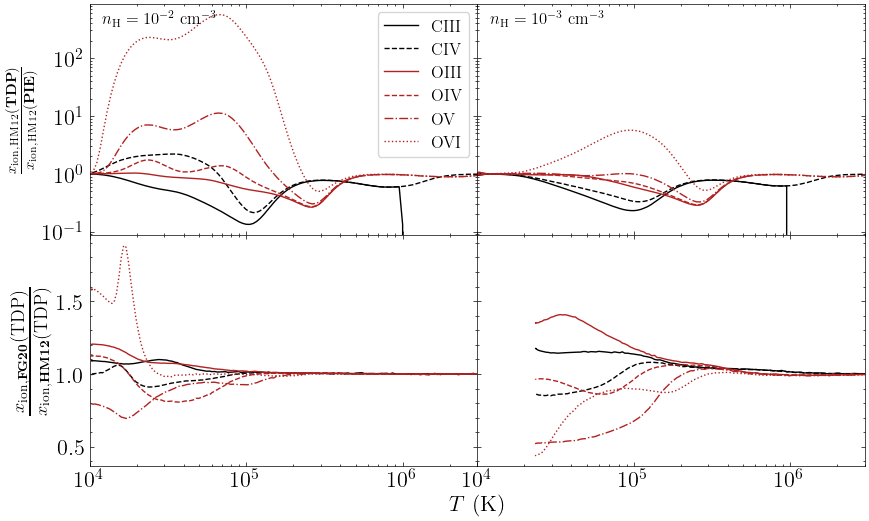

In [373]:
fig, axes = plt.subplots(2, 2, figsize = (2*5, 2*3), sharex=True, sharey='row')

for i in range(len(ion_list)):
    s = ion_list[i]
    axes[0,0].plot(T_dict_PIE_g17_hm12['-2'], 
                   X_dict_TDP_g17_hm12_interp['-2'][s]/X_dict_PIE_g17_hm12['-2'][s],
                  color=colorlist[i], linestyle=lslist[i], label=s)
    
axes[0,0].set_xscale('log')
axes[0,0].set_yscale('log')

axes[0,0].set_xlim(1e4, 3e6)

axes[0,0].set_ylabel(r'$\frac{x_\mathrm{ion, HM12} (\mathrm{\mathbf{TDP}})}{x_\mathrm{ion, HM12} (\mathrm{\mathbf{PIE}})}$', fontsize=15)
axes[0,0].text(1.2e4, 4e2, r'$n_\mathrm{H} = 10^{-2} \ \mathrm{cm}^{-3}$', fontsize=12)


axes[0,0].legend()

for i in range(len(ion_list)):
    s = ion_list[i]
    axes[0,1].plot(T_dict_PIE_g17_hm12['-3'], 
                   X_dict_TDP_g17_hm12_interp['-3'][s]/X_dict_PIE_g17_hm12['-3'][s],
                  color=colorlist[i], linestyle=lslist[i])
    
axes[0,1].text(1.2e4, 4e2, r'$n_\mathrm{H} = 10^{-3} \ \mathrm{cm}^{-3}$', fontsize=12)

for i in range(len(ion_list)):
    s = ion_list[i]
    axes[1,0].plot(T_dict_TDP_hm12['-2'], 
                   X_dict_TDP_fg20_interp['-2'][s]/X_dict_TDP_hm12['-2'][s],
                  color=colorlist[i], linestyle=lslist[i], label=s)
    
axes[1,0].set_xscale('log')
#axes[1,0].set_yscale('log')
#axes[1,0].set_ylim(1e-3, 9e-1)

for i in range(len(ion_list)):
    s = ion_list[i]
    axes[1,1].plot(T_dict_TDP_hm12['-3'], 
                   X_dict_TDP_fg20_interp['-3'][s]/X_dict_TDP_hm12['-3'][s],
                  color=colorlist[i], linestyle=lslist[i], label=s)
    
axes[1,0].set_ylabel(r'$\frac{x_\mathrm{ion, \mathbf{FG20}} (\mathrm{TDP})}{x_\mathrm{ion, \mathbf{HM12}} (\mathrm{TDP})}$', fontsize=19)

ax_label = fig.add_subplot(111, frameon=False)
# hide tick and tick label of the big axes
ax_label.set_xticks([])
ax_label.set_yticks([])

ax_label.set_xlabel(r'$T \ (\mathrm{K})$', labelpad=20)
#ax_label.set_ylabel(r'$\Lambda_{\mathrm{ion}} \ (\mathrm{erg} \ \mathrm{cm}^{3} \ \mathrm{s}^{-1})$', labelpad=45)

plt.subplots_adjust(wspace=0, hspace=0)

plt.savefig(rootdir+'TDP.pdf', dpi=300)